# 15 millones de personas cambiaron de país en 1990. En 2023 fueron 35 millones.

Y a casi ninguna la contaron una por una. Las estimó una red neuronal.

:::{image} figuras/pixabot.png
:alt: Mascota Pixabot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Los datos de migración tienen un problema viejo: son escasos, llegan tarde y cada país los define a su manera. Un equipo en Nature entrenó un conjunto de redes neuronales para reconstruir, año por año, cuánta gente se movió entre 230 países desde 1990 — con una banda de incertidumbre pegada a cada número. Aquí abrimos esos datos.

---

**Paper:** *Deep learning four decades of human migration* — Gaskin & Abel, **Nature** (2026)  
**DOI:** [10.1038/s41586-026-10611-7](https://doi.org/10.1038/s41586-026-10611-7)  
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-10-deep-learning-migracion-humana/notebook.ipynb)  
**Video:** [Ver en YouTube](https://youtube.com/shorts/ya1KCDnbaq8)

## Qué hay aquí dentro

El equipo fundió fuentes que normalmente no se hablan entre sí — estadísticas oficiales, censos de población nacida en el extranjero, estimaciones de migración neta, reconstrucciones de flujos pasados — en un solo marco. Por encima, un conjunto (*ensemble*) de redes neuronales recurrentes alimentadas con variables geográficas, económicas, culturales y políticas.

El resultado: un flujo migratorio anual origen-destino de 1990 a 2023, para 231 países y regiones. **Cada cifra es una estimación del modelo, no un conteo de cabezas** — por eso viene con su desviación estándar. Esa banda de error es la parte más honesta del dataset, y vamos a usarla en cada gráfica.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANIO_INICIO   = 1990
ANIO_FIN      = 2023
FUENTE        = 'Fuente: Gaskin & Abel (2026), Nature | Datos: ThGaskin/Migration_flows (HuggingFace)'
COLOR_DATOS   = '#2563EB'   # azul CaM — flujo principal
COLOR_ALERTA  = '#DC2626'   # rojo — shock / referencia
COLOR_SEC     = '#059669'   # emerald — serie secundaria
COLOR_REF     = '#D97706'   # amber — umbral
COLOR_CTX     = '#BBBBBB'   # gris — contexto

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Nombres en español para los códigos ISO3 que usaremos
NOMBRES = {
    'USA':'Estados Unidos','SAU':'Arabia Saudí','IND':'India','DEU':'Alemania',
    'GBR':'Reino Unido','SDN':'Sudán','ESP':'España','COL':'Colombia',
    'ARE':'Emiratos Árabes','EGY':'Egipto','PAK':'Pakistán','BGD':'Bangladés',
    'UKR':'Ucrania','VEN':'Venezuela','CHN':'China','PHL':'Filipinas',
    'SYR':'Siria','SSD':'Sudán del Sur','IDN':'Indonesia','CAN':'Canadá','TCD':'Chad',
}

# Carga
glob   = pd.read_csv('datos/migracion_global_por_anio.csv')
pais   = pd.read_csv('datos/migracion_por_pais_anio.csv')
shocks = pd.read_csv('datos/shocks_emigracion_serie.csv')

g = glob[(glob.year >= ANIO_INICIO) & (glob.year <= ANIO_FIN)].copy()
imm_1990 = g.loc[g.year==1990, 'imm_total'].values[0]
imm_2023 = g.loc[g.year==2023, 'imm_total'].values[0]
pico = g.loc[g.imm_total.idxmax()]

print(f'Países y regiones: {int(glob.imm_pop_total.notna().sum() and pais.iso3.nunique())}')
print(f'Filas país-año:    {len(pais):,}'.replace(',', '.'))
print(f'Flujo global 1990: {imm_1990/1e6:.1f} M de personas')
print(f'Flujo global 2023: {imm_2023/1e6:.1f} M de personas')
print(f'Crecimiento:       x{imm_2023/imm_1990:.2f}')
print(f'Pico:              {int(pico.year)} con {pico.imm_total/1e6:.1f} M')

Países y regiones: 231
Filas país-año:    8.085
Flujo global 1990: 15.2 M de personas
Flujo global 2023: 34.7 M de personas
Crecimiento:       x2.28
Pico:              2022 con 35.6 M


## El flujo, año por año

Aquí está.

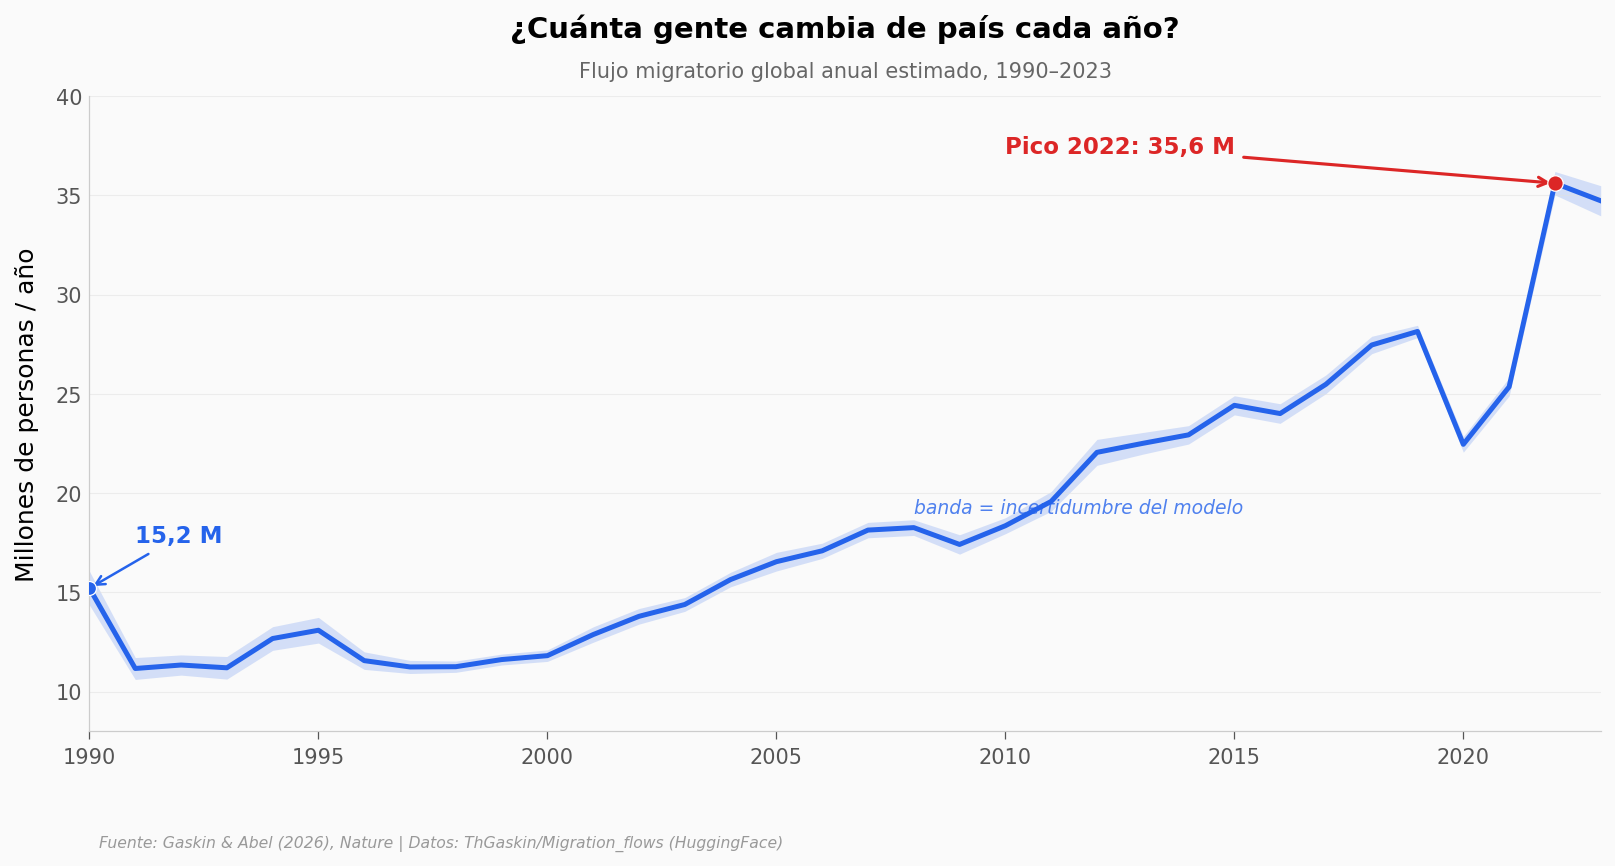

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x   = g.year.values
y   = g.imm_total.values / 1e6
err = g.imm_total_std.values / 1e6

# Banda de incertidumbre del modelo (±1 desviación estándar)
ax.fill_between(x, y - err, y + err, color=COLOR_DATOS, alpha=0.18, linewidth=0)
ax.plot(x, y, color=COLOR_DATOS, linewidth=2.4, zorder=5)

# Marcar inicio y pico
ax.scatter([1990], [imm_1990/1e6], color=COLOR_DATOS, s=45, zorder=6,
           edgecolors='white', linewidths=0.6)
ax.scatter([int(pico.year)], [pico.imm_total/1e6], color=COLOR_ALERTA, s=55, zorder=6,
           edgecolors='white', linewidths=0.6)
ax.annotate(f'{imm_1990/1e6:.1f} M'.replace('.', ','), xy=(1990, imm_1990/1e6),
            xytext=(1991, 17.5), fontsize=11, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.2))
ax.annotate(f'Pico {int(pico.year)}: {pico.imm_total/1e6:.1f} M'.replace('.', ','),
            xy=(int(pico.year), pico.imm_total/1e6),
            xytext=(int(pico.year)-12, pico.imm_total/1e6 + 1.5), fontsize=11,
            fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.text(2008, 19, 'banda = incertidumbre del modelo', fontsize=9,
        color=COLOR_DATOS, style='italic', alpha=0.8)

ax.set_title('¿Cuánta gente cambia de país cada año?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Flujo migratorio global anual estimado, 1990–2023',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Millones de personas / año')
ax.set_xlim(1990, 2023)
ax.set_ylim(8, 40)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/flujo_global.png', dpi=200, bbox_inches='tight')
plt.show()

El flujo se duplica con creces en tres décadas: de 15,2 a 34,7 millones por año, un factor de **2,28**. No es una subida suave — hay un escalón claro tras 2015 y un máximo en 2022, con 35,6 millones.

Fíjate en lo angosta que es la banda azul. A escala global el modelo está muy seguro: la incertidumbre ronda apenas el 2% del total. Eso pasa porque los errores de cada país, al ser independientes, tienden a cancelarse cuando los sumas. Guarda ese dato — más abajo vamos a ver qué ocurre cuando dejas de sumar y miras país por país.

## Cuando estalla una crisis

El promedio global esconde los sobresaltos. Si el modelo sirve, debería captar el momento exacto en que una guerra o un colapso económico vacía un país. Veamos tres casos.

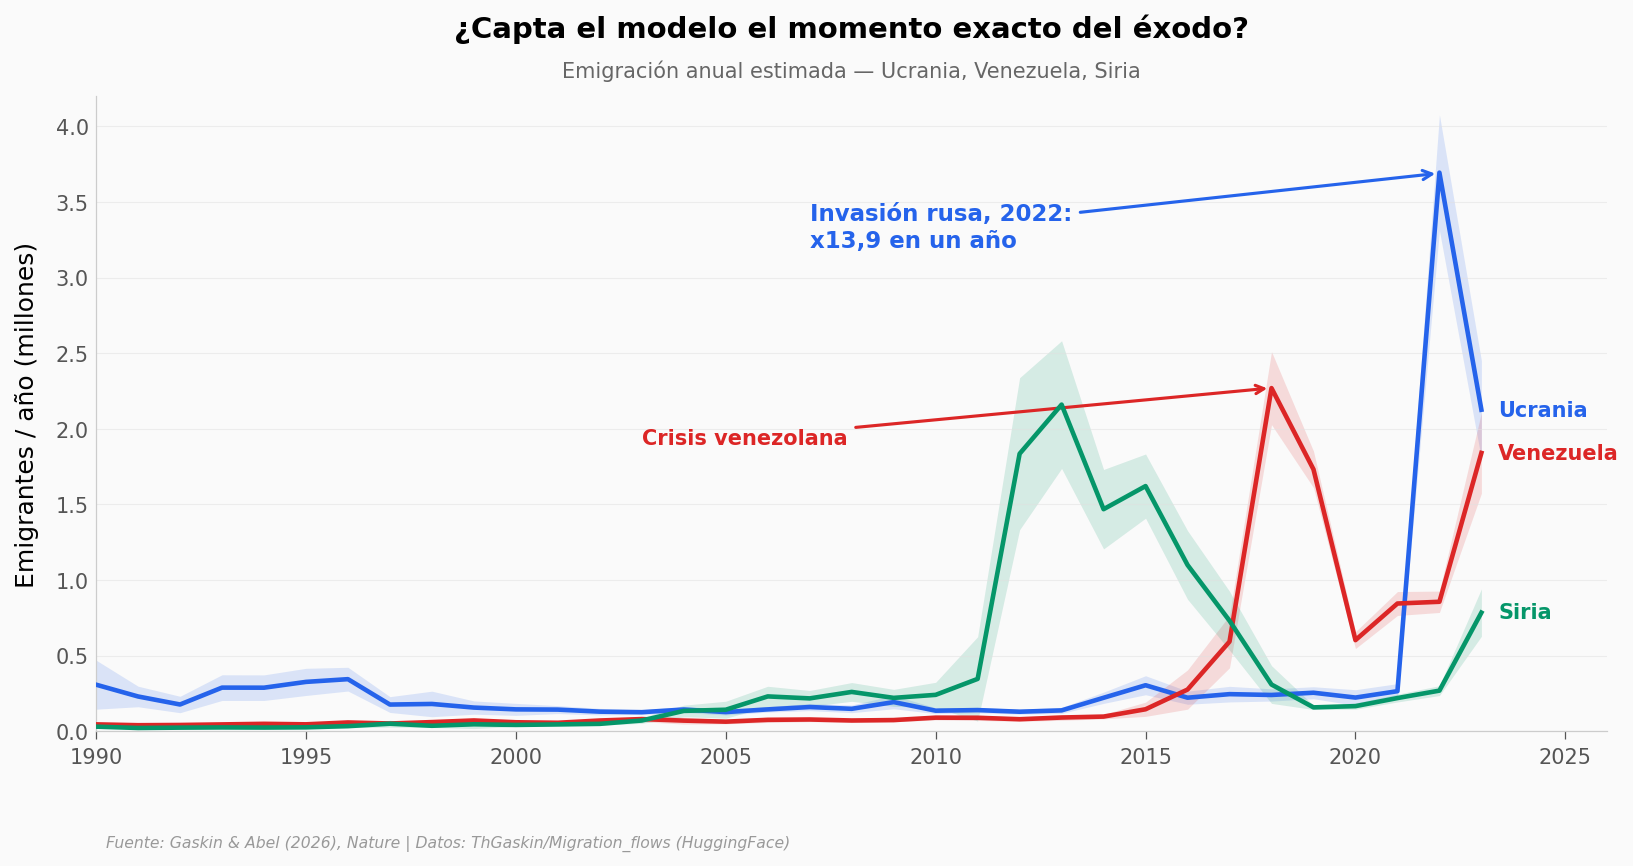

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

series = [('UKR', COLOR_DATOS), ('VEN', COLOR_ALERTA), ('SYR', COLOR_SEC)]
for iso, color in series:
    d = shocks[shocks.iso3 == iso].sort_values('year')
    yv = d.emi.values / 1e6
    ev = d.emi_std.values / 1e6
    ax.fill_between(d.year, yv - ev, yv + ev, color=color, alpha=0.15, linewidth=0)
    ax.plot(d.year, yv, color=color, linewidth=2.2, zorder=5)
    ax.text(d.year.values[-1] + 0.4, yv[-1], NOMBRES[iso], fontsize=10,
            color=color, fontweight='bold', va='center')

# Anotar el salto de Ucrania 2022
ax.annotate('Invasión rusa, 2022:\nx13,9 en un año',
            xy=(2022, 3.69), xytext=(2007, 3.2), fontsize=11, fontweight='bold',
            color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax.annotate('Crisis venezolana',
            xy=(2018, 2.27), xytext=(2003, 1.9), fontsize=10, fontweight='bold',
            color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Capta el modelo el momento exacto del éxodo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Emigración anual estimada — Ucrania, Venezuela, Siria',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Emigrantes / año (millones)')
ax.set_xlim(1990, 2026)
ax.set_ylim(0, 4.2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/shocks.png', dpi=200, bbox_inches='tight')
plt.show()

El salto de Ucrania en 2022 es brutal: la emigración pasa de 265 mil a 3,69 millones en un solo año — casi catorce veces más. Y la banda de error se ensancha justo ahí, donde los datos sobre el terreno escasean.

Eso nos lleva al panorama de 2023: ¿quién recibe y quién pierde gente?

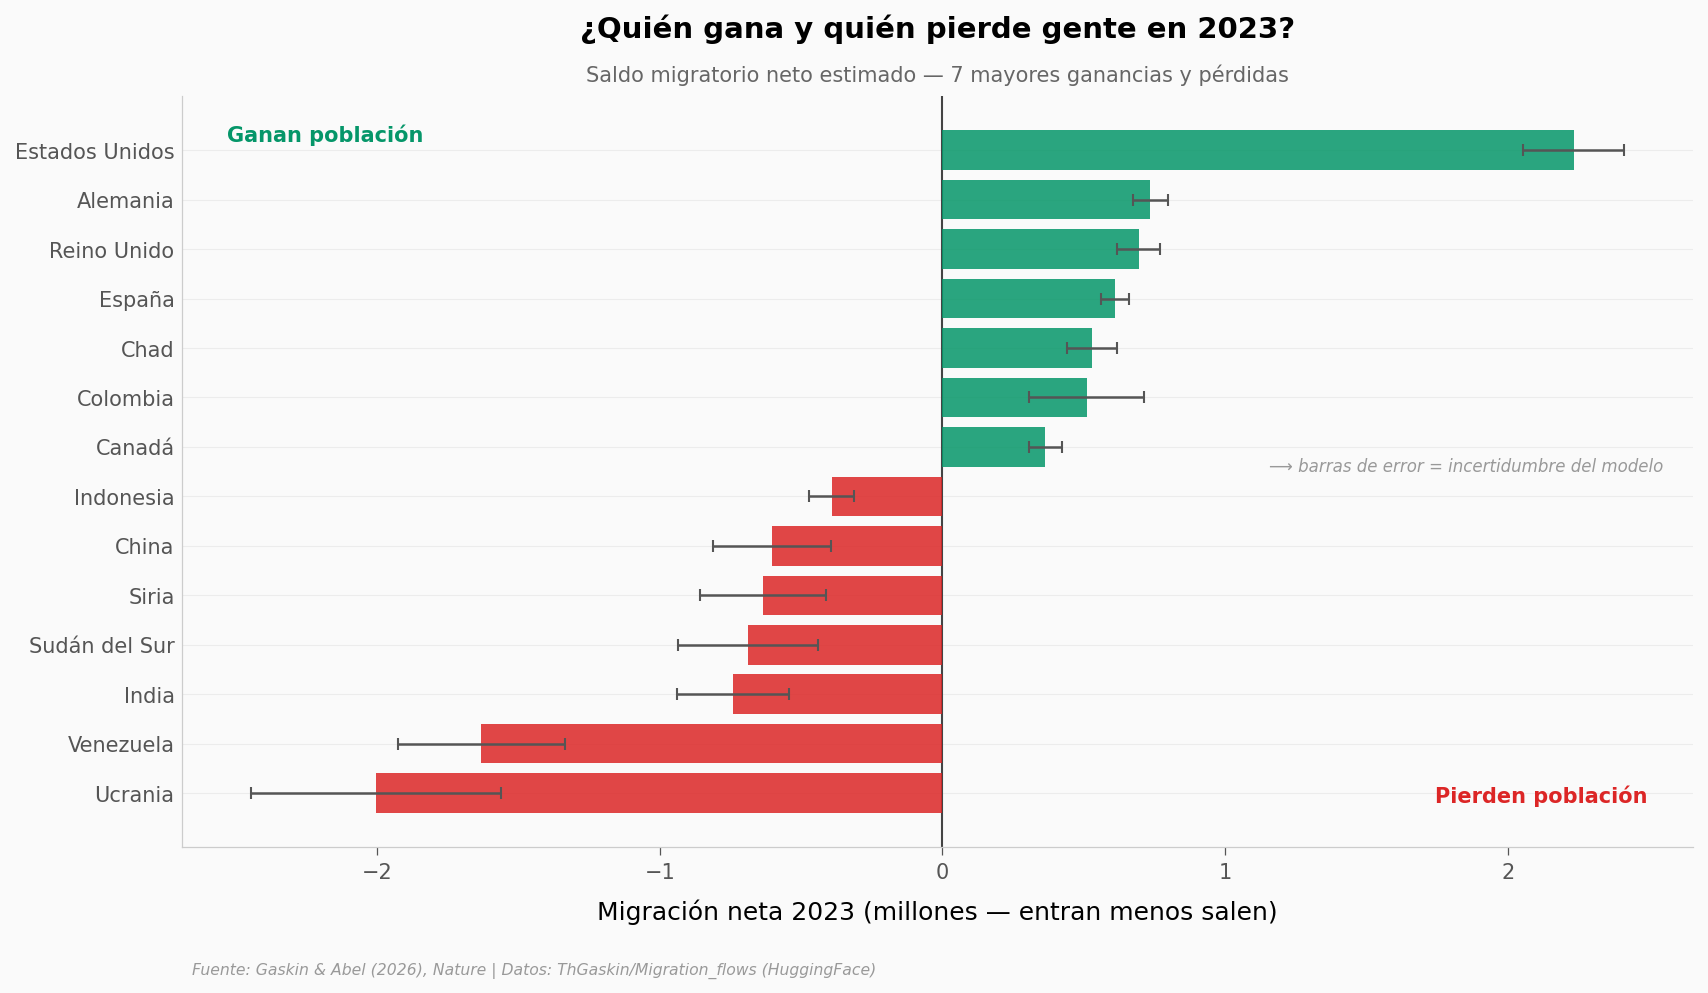

In [4]:
p23 = pais[pais.year == 2023].copy().sort_values('net')
bot = p23.head(7)   # pierden más
top = p23.tail(7)   # ganan más
sel = pd.concat([bot, top])

fig, ax = plt.subplots(figsize=(13, 6.5))
ypos = np.arange(len(sel))
vals = sel.net.values / 1e6
errs = sel.net_std.values / 1e6
colors = [COLOR_SEC if v > 0 else COLOR_ALERTA for v in vals]

ax.barh(ypos, vals, color=colors, alpha=0.85, zorder=3)
ax.errorbar(vals, ypos, xerr=errs, fmt='none', ecolor='#555555',
            elinewidth=1.2, capsize=3, zorder=4)
ax.axvline(0, color='#444444', linewidth=1.0)

labels = [NOMBRES.get(i, i) for i in sel.iso3]
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Migración neta 2023 (millones — entran menos salen)')

# Barras ordenadas: ganadores arriba (verde), perdedores abajo (rojo)
ax.text(0.03, 0.94, 'Ganan población', transform=ax.transAxes, ha='left',
        fontsize=10, fontweight='bold', color=COLOR_SEC)
ax.text(0.97, 0.06, 'Pierden población', transform=ax.transAxes, ha='right',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA)
ax.text(0.98, 0.50, '⟶ barras de error = incertidumbre del modelo',
        transform=ax.transAxes, ha='right', fontsize=8, color='#999999', style='italic')

ax.set_title('¿Quién gana y quién pierde gente en 2023?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.02, 'Saldo migratorio neto estimado — 7 mayores ganancias y pérdidas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/migracion_neta.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan seguro está el modelo?

Vimos que a escala global la incertidumbre es minúscula. Pero esa cifra suma el mundo entero. ¿Qué pasa cuando bajas a cada país por separado? Aquí está el reparto.

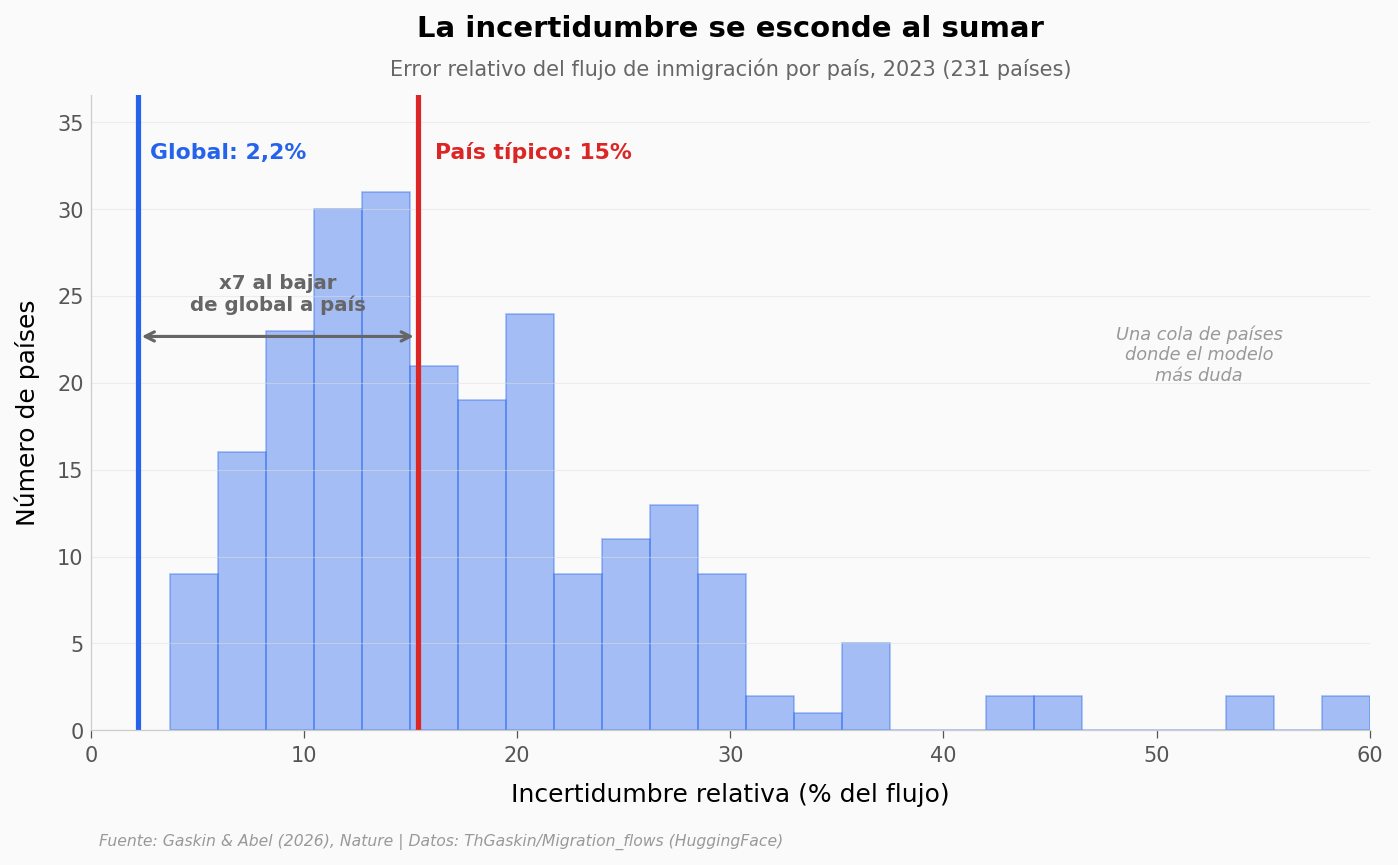

In [5]:
p23 = pais[pais.year == 2023].copy()
p23['imm_rel'] = p23['imm_std'] / p23['imm'].abs() * 100
rel = p23['imm_rel'].clip(upper=60)   # cap visual; 2 países (0,9%) pasan de 60

g23 = glob[glob.year == 2023].iloc[0]
global_rel = g23.imm_total_std / g23.imm_total * 100
mediana_rel = p23['imm_rel'].median()

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, _ = ax.hist(rel, bins=25, color=COLOR_DATOS, alpha=0.4,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

ax.axvline(global_rel, color=COLOR_DATOS, linewidth=2.5)
ax.axvline(mediana_rel, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(mediana_rel, y_max*0.62), xytext=(global_rel, y_max*0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((global_rel + mediana_rel)/2, y_max*0.66, 'x7 al bajar\nde global a país',
        ha='center', fontsize=9.5, color='#666666', fontweight='bold')

ax.text(global_rel + 0.6, y_max*0.90, f'Global: {global_rel:.1f}%'.replace('.', ','),
        fontsize=10.5, fontweight='bold', color=COLOR_DATOS)
ax.text(mediana_rel + 0.8, y_max*0.90, f'País típico: {mediana_rel:.0f}%',
        fontsize=10.5, fontweight='bold', color=COLOR_ALERTA)
ax.text(52, y_max*0.55, 'Una cola de países\ndonde el modelo\nmás duda',
        fontsize=8.5, color='#999999', ha='center', style='italic')

ax.set_title('La incertidumbre se esconde al sumar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Error relativo del flujo de inmigración por país, 2023 (231 países)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Incertidumbre relativa (% del flujo)')
ax.set_ylabel('Número de países')
ax.set_xlim(0, 60)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/incertidumbre.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El flujo global anual crece x2,28 entre 1990 y 2023 (15,2 → 34,7 M) | ✅ | Lectura directa del agregado global; std 2023 ≈ 0,76 M (2,2%) |
| El máximo de flujo es 2022, con 35,6 M | ✅ | Año de máxima en el agregado; el paper lo enmarca como estimación del modelo |
| La emigración de Ucrania salta x13,9 entre 2021 y 2022 | ✅ | 265 k → 3,69 M; coincide con la invasión rusa. La banda de error se ensancha (±325 k) |
| La incertidumbre es ~2% global pero ~15% por país | ✅ | Mediana de error relativo por país = 15,3%; agregado global = 2,2% |
| El modelo «supera» estimaciones previas de 5 años | ⚠️ | El abstract lo afirma sobre datos reservados, pero no extrajimos la magnitud exacta — no la inventamos |

> **Limitaciones:** todas las cifras son **estimaciones de un modelo**, no conteos directos — por eso cada una trae su desviación estándar. La incertidumbre es mayor justo donde más importa: zonas de crisis con recolección de datos débil (Ucrania ±325 k, Venezuela ±267 k, Sudán del Sur ±247 k). El propio paper señala que ese error alto marca dónde urge medir mejor. Los flujos no implican causa: el modelo describe cuánta gente se movió, no por qué.

## Ahora tú

Los datos están cargados en `pais` (país-año) y `glob` (agregado global). Tres preguntas para hurgar:

1. **¿Cómo se ve tu país?** Filtra `pais[pais.iso3 == 'COL']` y grafica su migración neta año por año. ¿Cuándo cambió de signo? *(pista: Colombia gana +509 k en 2023)*
2. **¿Y el stock acumulado?** Las columnas `imm_pop` / `emi_pop` son el total de migrantes viviendo en/fuera de un país, no el flujo anual. ¿Crece igual de rápido que el flujo?
3. **¿Dónde el modelo duda más?** Ordena los países de 2023 por `emi_std` y mira los primeros. ¿Coinciden con conflictos activos?

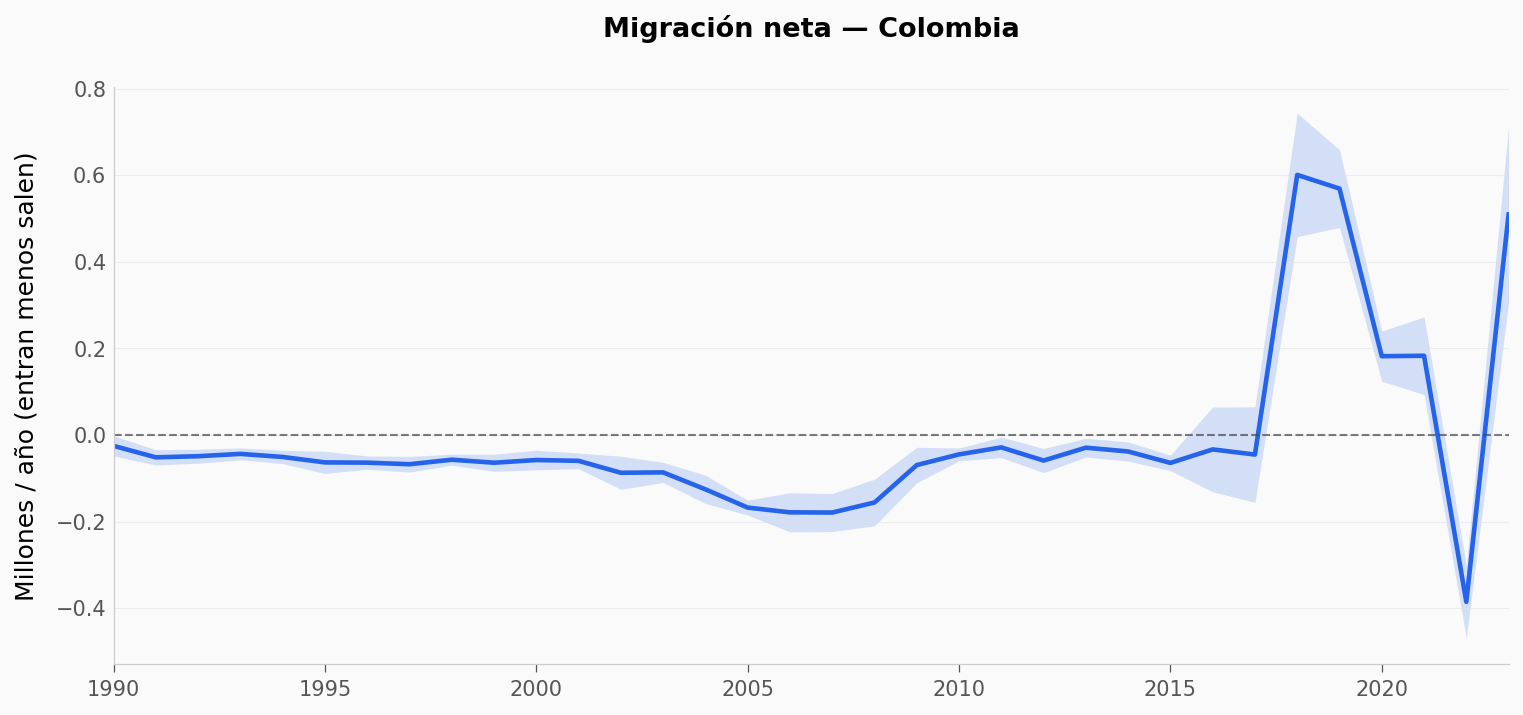

Colombia: net 2023 = +0.51 M


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Migración neta de un país, año por año, con su banda de incertidumbre.
PAIS = 'COL'   # prueba con 'VEN', 'UKR', 'DEU', 'IND'...

d = pais[pais.iso3 == PAIS].sort_values('year')
fig, ax = plt.subplots(figsize=(12, 5))
yv = d.net.values / 1e6
ev = d.net_std.values / 1e6
ax.fill_between(d.year, yv - ev, yv + ev, color=COLOR_DATOS, alpha=0.18, linewidth=0)
ax.plot(d.year, yv, color=COLOR_DATOS, linewidth=2.2)
ax.axhline(0, color='#444444', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_title(f'Migración neta — {NOMBRES.get(PAIS, PAIS)}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Millones / año (entran menos salen)')
ax.set_xlim(1990, 2023)
plt.show()
print(f'{NOMBRES.get(PAIS, PAIS)}: net 2023 = {d[d.year==2023].net.values[0]/1e6:+.2f} M')

## Créditos

Notebook reproducible de **Ciencia a Mordiscos** · El Lab.  
Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-06-10-deep-learning-migracion-humana)

Los datos, el código y los modelos entrenados del paper son públicos (licencia abierta del repositorio original).

## Fuentes

**Paper**: [Deep learning four decades of human migration](https://doi.org/10.1038/s41586-026-10611-7)  
*Nature, 2026-06-10*

**Datos**: [ThGaskin/Migration_flows — Deep learning-based estimates of global migration flows (mig_unilateral.csv)](https://huggingface.co/datasets/ThGaskin/Migration_flows)

*15 afirmaciones verificadas contra estas fuentes*